In [15]:
import sys
sys.path.append('/mnt/home/igaron/gplvm')
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
import jaxopt
from jax.nn import softplus

import matplotlib.pyplot as plt
from tqdm import tqdm 

import utils
import mappings
import loader
import noise_models
from core import GPLVM, DynamicGPLVM, Layer, Proposal
from mc_samplers import Roberts, UniformSobol

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Timesteps x Neurons: (927, 18)


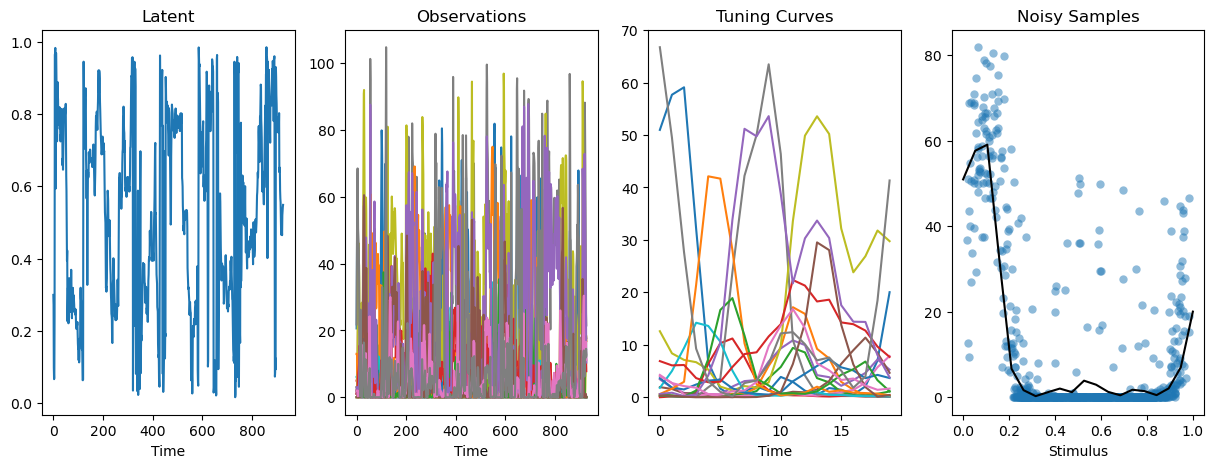

In [16]:
# Data path
filepath = '/mnt/home/neurostatslab/ceph/thalamus/adn_fenton/HD_data_all_vJose.pkl'
data = loader.FentonHeaddir(filepath)
mouse = 3
epoch = "fr_light"
bin_size = 10 # already binned at 20ms -> 200ms timebins
ys = data.load_data(mouse, epoch, bin_size, filter_locomotion=True, normed = True)

num_dims = 1
num_steps, num_neurons = ys[0].shape

tuning = data.get_tuning(20,num_neurons, ys[0], ys[1])
utils.plot_real_data_1D(ys[1], ys[0], tuning, n_neurs=30);


# LBFGS

100%|█████████████████| 1000/1000 [00:08<00:00, 123.05it/s]


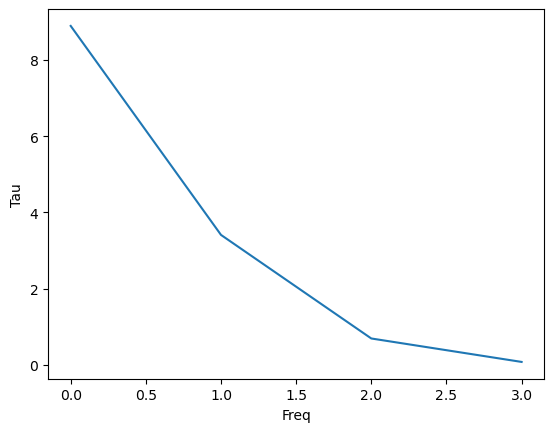

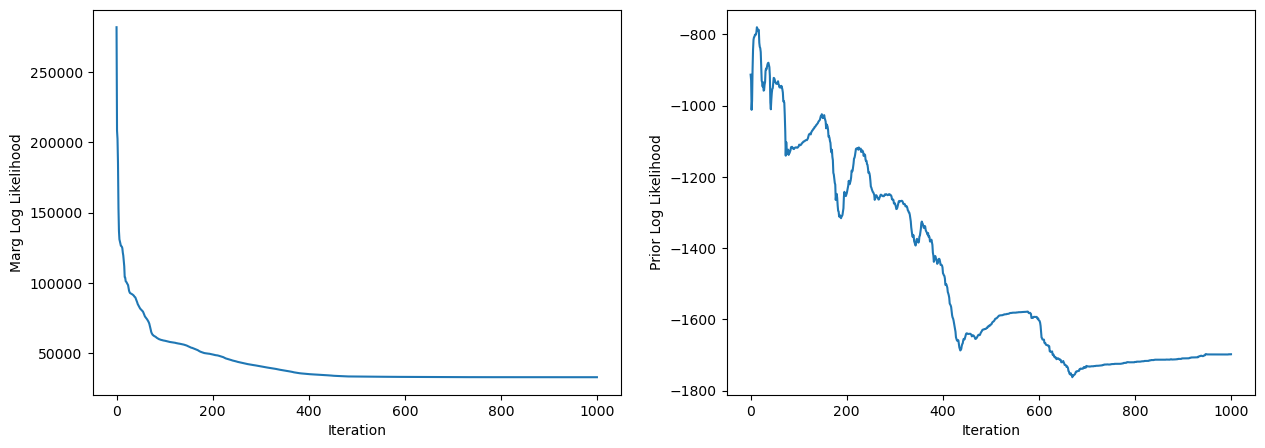

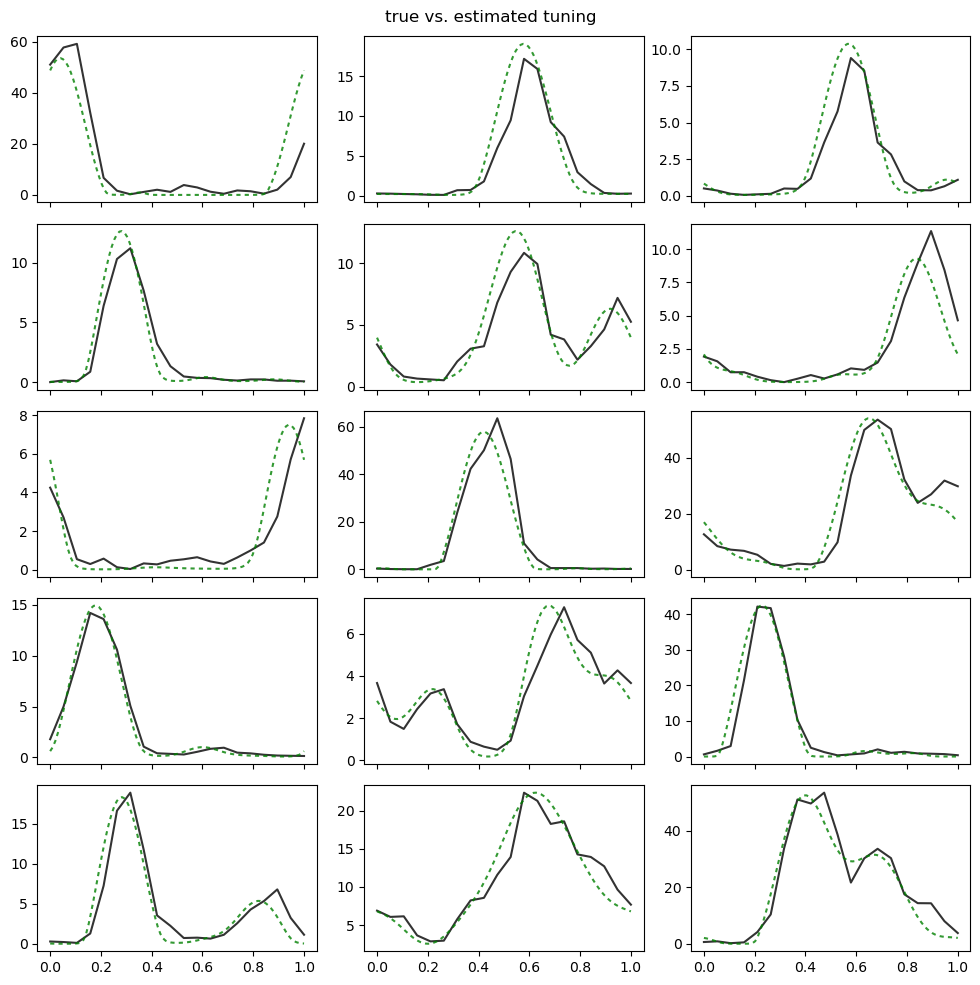

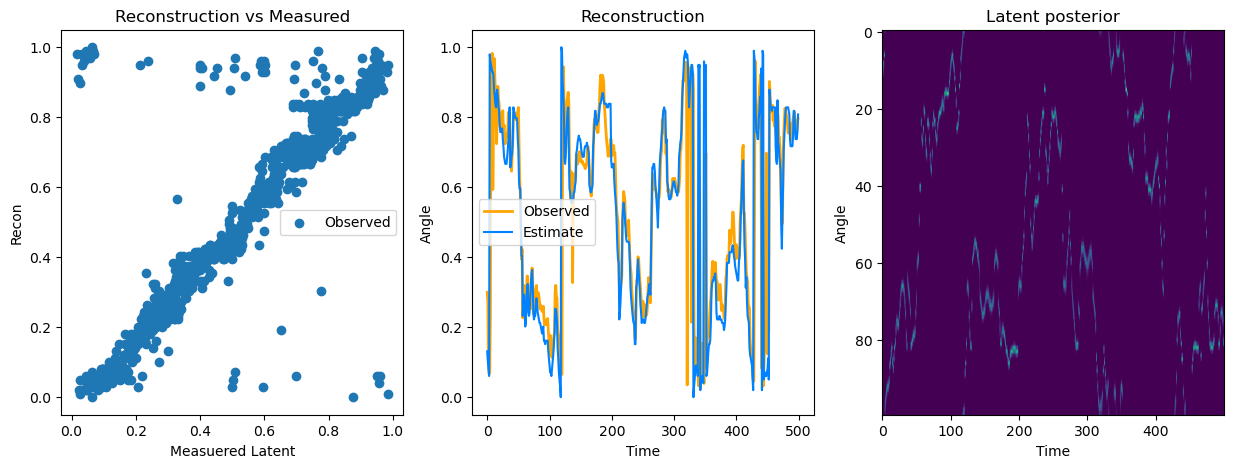

In [17]:
num_dims = 1
num_steps, num_neurons = ys[0].shape


# Tuning prior
basis_params = {
                "max_freq": 40, 
                "num_dims": num_dims, 
                "out_scale":150., 
                "len_scale":.18,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-3,
                "nonlinearity":lambda x: softplus(x),
                }


# KEY DUMP
INIT_KEY = jax.random.PRNGKey(9)
OPT_KEY = jax.random.PRNGKey(123)
IS_KEY = jax.random.PRNGKey(8)

# Construct model
model = GPLVM(
    observation=Layer(
        mapping=mappings.EIVMapping([mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()]),
        noise=noise_models.EIVNoiseModel([noise_models.Poisson(),noise_models.VonMisesNormed(10.)]), 
    ),
    sampler = Roberts(), num_samples = 512)
params_per_neuron = model.params_per_neuron


plt.figure()
plt.plot(model.observation.mapping.mappings[0].ttau)
plt.xlabel("Freq")
plt.ylabel("Tau")

est_params = est_params = jax.random.normal(
                            INIT_KEY, 
                            shape=(params_per_neuron, num_neurons)
                    )


opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "n_iters":  1000
}

model.fit(ys, "lbfgs", opt_params)
    
utils.plot_objhist(model);

utils.plot_real_tuning(model, tuning, grid_max = 1, grid_reso=100, ula_flag = False)
utils.plot_latent_recon_real(model, ys, grid_reso = 100, window = 500, grid_max = 1)

# ULA

100%|████████████████████| 500/500 [00:08<00:00, 59.15it/s]


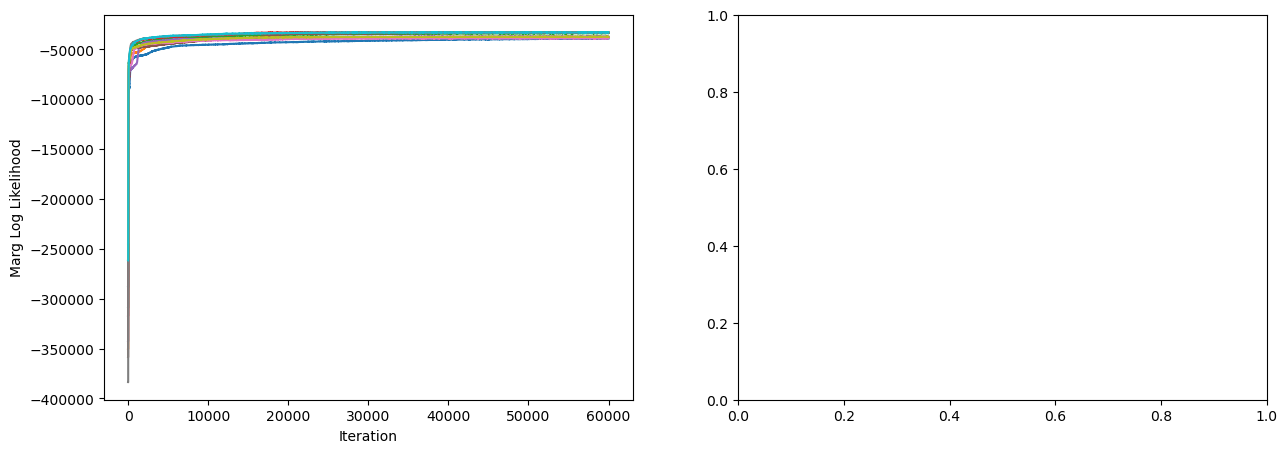

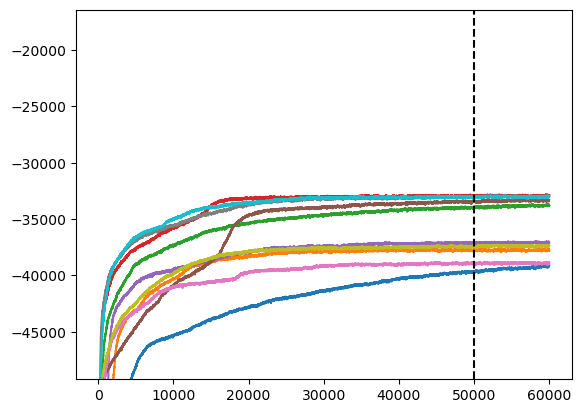

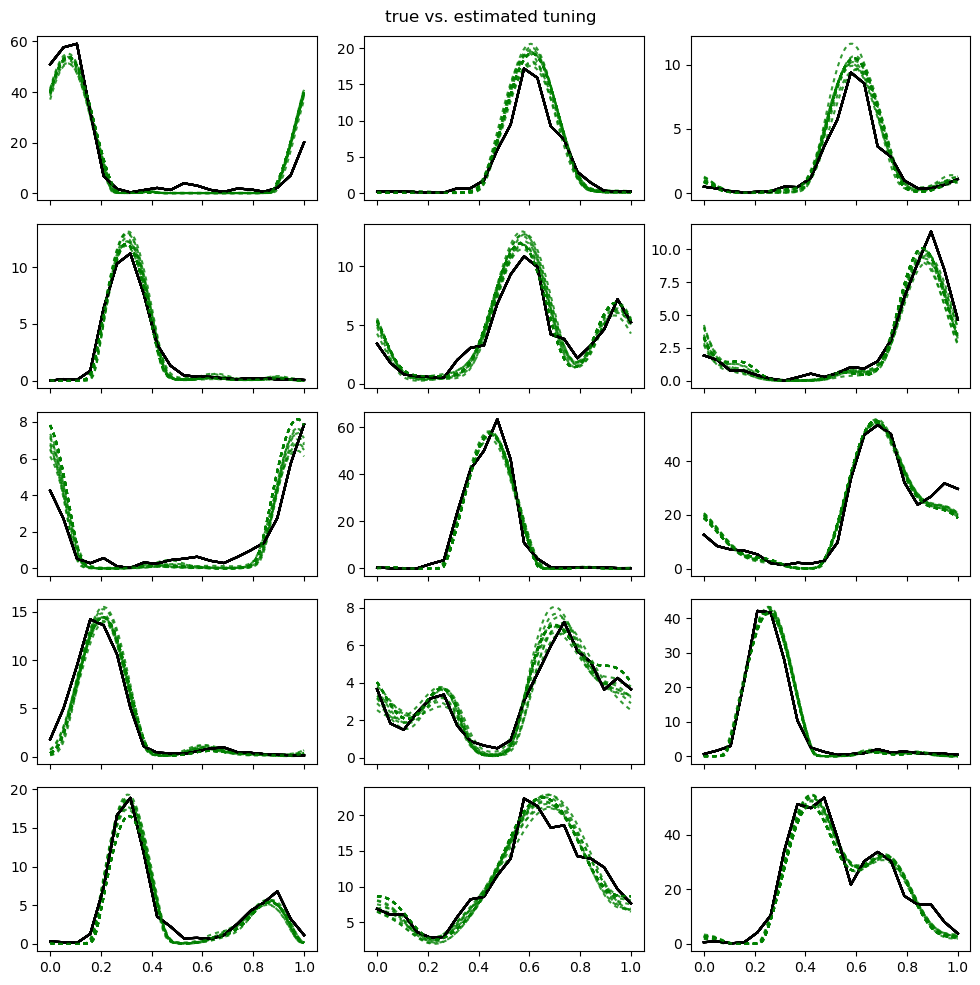

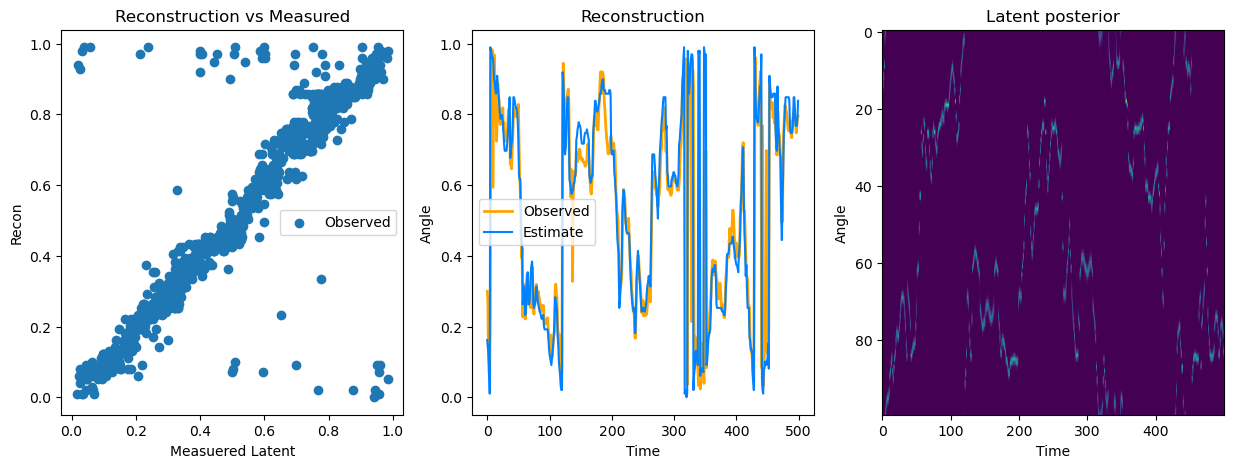

In [18]:
model = GPLVM(
    observation=Layer(
        mapping=mappings.EIVMapping([mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()]),
        noise=noise_models.EIVNoiseModel([noise_models.Poisson(),noise_models.VonMisesNormed(5.)]), 
    ),
    sampler = Roberts(), num_samples = 512)
    
params_per_neuron = model.params_per_neuron


est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(10, params_per_neuron, num_neurons)
                    ) 
opt_params = {
    "init_params":est_params,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "is_key":IS_KEY,
    "n_iters": 60000,
    "n_chains": 10,
    "friction":0.1,
    "min_lr": 1e-6,
    "max_lr": 1e-5,
    "noise_multiplier":2.,
    "burn_in":50000,
    "save_every":1000,
    "params_per_neuron":params_per_neuron,
    "num_neurons":num_neurons
}

model.fit(ys, "ula", opt_params)

utils.plot_objhist(model, show_prior = False);

plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/2, jnp.max(model.objhist_)-jnp.max(model.objhist_)/2)
plt.axvline(opt_params["burn_in"], color='k', linestyle="--")

utils.plot_real_tuning(model, tuning.T, grid_max = 1, grid_reso=100, ula_flag = True)
utils.plot_latent_recon_real(model, ys, grid_reso = 100, window = 500, grid_max = 1, ula_flag = True)